In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
df=pd.read_csv("/kaggle/input/orbits-orbits-csv/orbits - orbits.csv")

In [3]:
df.head()

,Object Name,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,Classification,Hazardous
0,433 Eros,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,Amor Asteroid,False
1,719 Albert,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,Amor Asteroid,False
2,887 Alinda,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,Amor Asteroid,False
3,1036 Ganymed,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,Amor Asteroid,False
4,1221 Amor,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,Amor Asteroid,False


In [4]:
df.shape

(15635, 16)

In [5]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
lb1=LabelEncoder()
df['classification']=lb.fit_transform(df['Classification'])
df['hazardous']=lb1.fit_transform(df['Hazardous'])

df.head(50)

,Object Name,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,Classification,Hazardous,classification,hazardous
0,433 Eros,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,Amor Asteroid,False,0,0
1,719 Albert,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,Amor Asteroid,False,0,0
2,887 Alinda,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,Amor Asteroid,False,0,0
3,1036 Ganymed,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,Amor Asteroid,False,0,0
4,1221 Amor,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,Amor Asteroid,False,0,0
5,1566 Icarus,57800,1.0781,0.8269,22.8255,31.3830,88.0107,215.5288,0.1867,1.97,1.12,0.0345,100,16.90,Apollo Asteroid,True,2,1
6,1580 Betulia,57800,2.1973,0.4875,52.0908,159.4852,62.2921,191.9105,1.1260,3.27,3.26,0.1361,191,14.80,Amor Asteroid,False,0,0
7,1620 Geographos,57800,1.2453,0.3353,13.3375,276.8930,337.2080,104.1556,0.8277,1.66,1.39,0.0307,449,15.60,Apollo Asteroid,True,2,1
8,1627 Ivar,57800,1.8628,0.3966,8.4512,167.7730,133.1445,151.4603,1.1241,2.60,2.54,0.1124,635,13.20,Amor Asteroid,False,0,0
9,1685 Toro,54520,1.3673,0.4359,9.3807,127.0826,274.3396,48.6229,0.7713,1.96,1.60,0.0504,355,14.23,Apollo Asteroid,False,2,0


In [6]:
x=lb.inverse_transform([0,1,2,3])
print(x)

['Amor Asteroid' 'Apohele Asteroid' 'Apollo Asteroid' 'Aten Asteroid']


In [7]:
df.drop(['Object Name','Classification','Hazardous'],axis=1,inplace=True)
df.head()

,Epoch (TDB),Orbit Axis (AU),Orbit Eccentricity,Orbit Inclination (deg),Perihelion Argument (deg),Node Longitude (deg),Mean Anomoly (deg),Perihelion Distance (AU),Aphelion Distance (AU),Orbital Period (yr),Minimum Orbit Intersection Distance (AU),Orbital Reference,Asteroid Magnitude,classification,hazardous
0,57800,1.4579,0.2226,10.8277,178.8050,304.3265,319.3111,1.1335,1.78,1.76,0.1492,598,11.16,0,0
1,57800,2.6385,0.5479,11.5822,156.1409,183.9204,224.5535,1.1928,4.08,4.29,0.2004,78,15.50,0,0
2,57800,2.4787,0.5671,9.3561,350.3482,110.5444,351.3730,1.0731,3.88,3.90,0.0925,188,13.40,0,0
3,57800,2.6628,0.5338,26.6929,132.4690,215.5551,92.5640,1.2413,4.08,4.35,0.3421,597,9.45,0,0
4,57800,1.9191,0.4356,11.8795,26.6572,171.3448,313.7379,1.0832,2.76,2.66,0.1068,70,17.70,0,0


In [8]:
df=df.dropna()
df.shape

(15634, 15)

In [9]:
df.isnull().sum()

Epoch (TDB)                                 0
Orbit Axis (AU)                             0
Orbit Eccentricity                          0
Orbit Inclination (deg)                     0
Perihelion Argument (deg)                   0
Node Longitude (deg)                        0
Mean Anomoly (deg)                          0
Perihelion Distance (AU)                    0
Aphelion Distance (AU)                      0
Orbital Period (yr)                         0
Minimum Orbit Intersection Distance (AU)    0
Orbital Reference                           0
Asteroid Magnitude                          0
classification                              0
hazardous                                   0
dtype: int64

<Axes: >

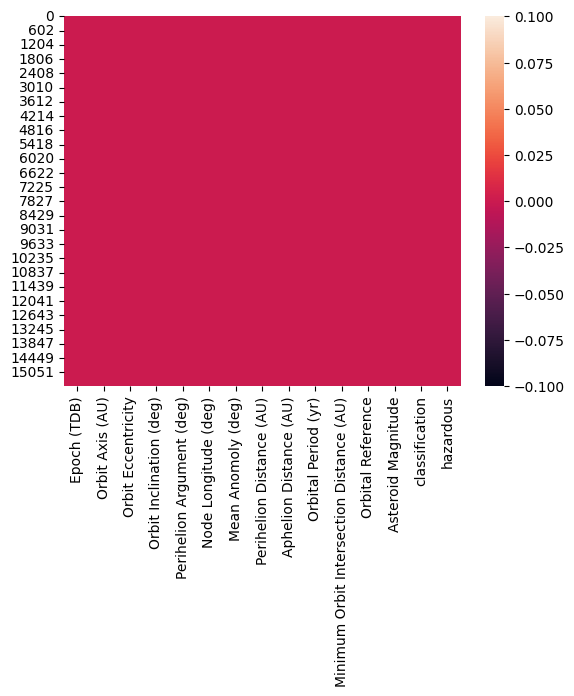

In [10]:
sns.heatmap(df.isnull())

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


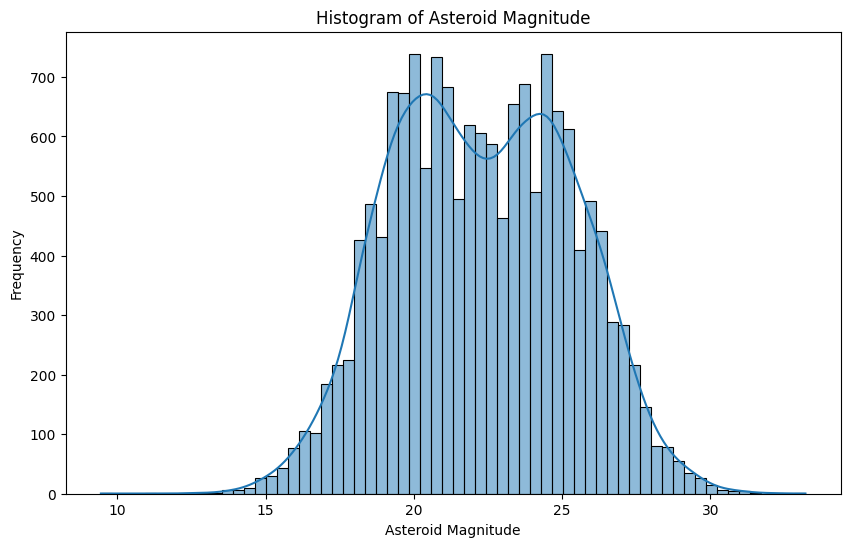

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Asteroid Magnitude'], kde=True) 
plt.title('Histogram of Asteroid Magnitude') 
plt.xlabel('Asteroid Magnitude') 
plt.ylabel('Frequency') 
plt.show()

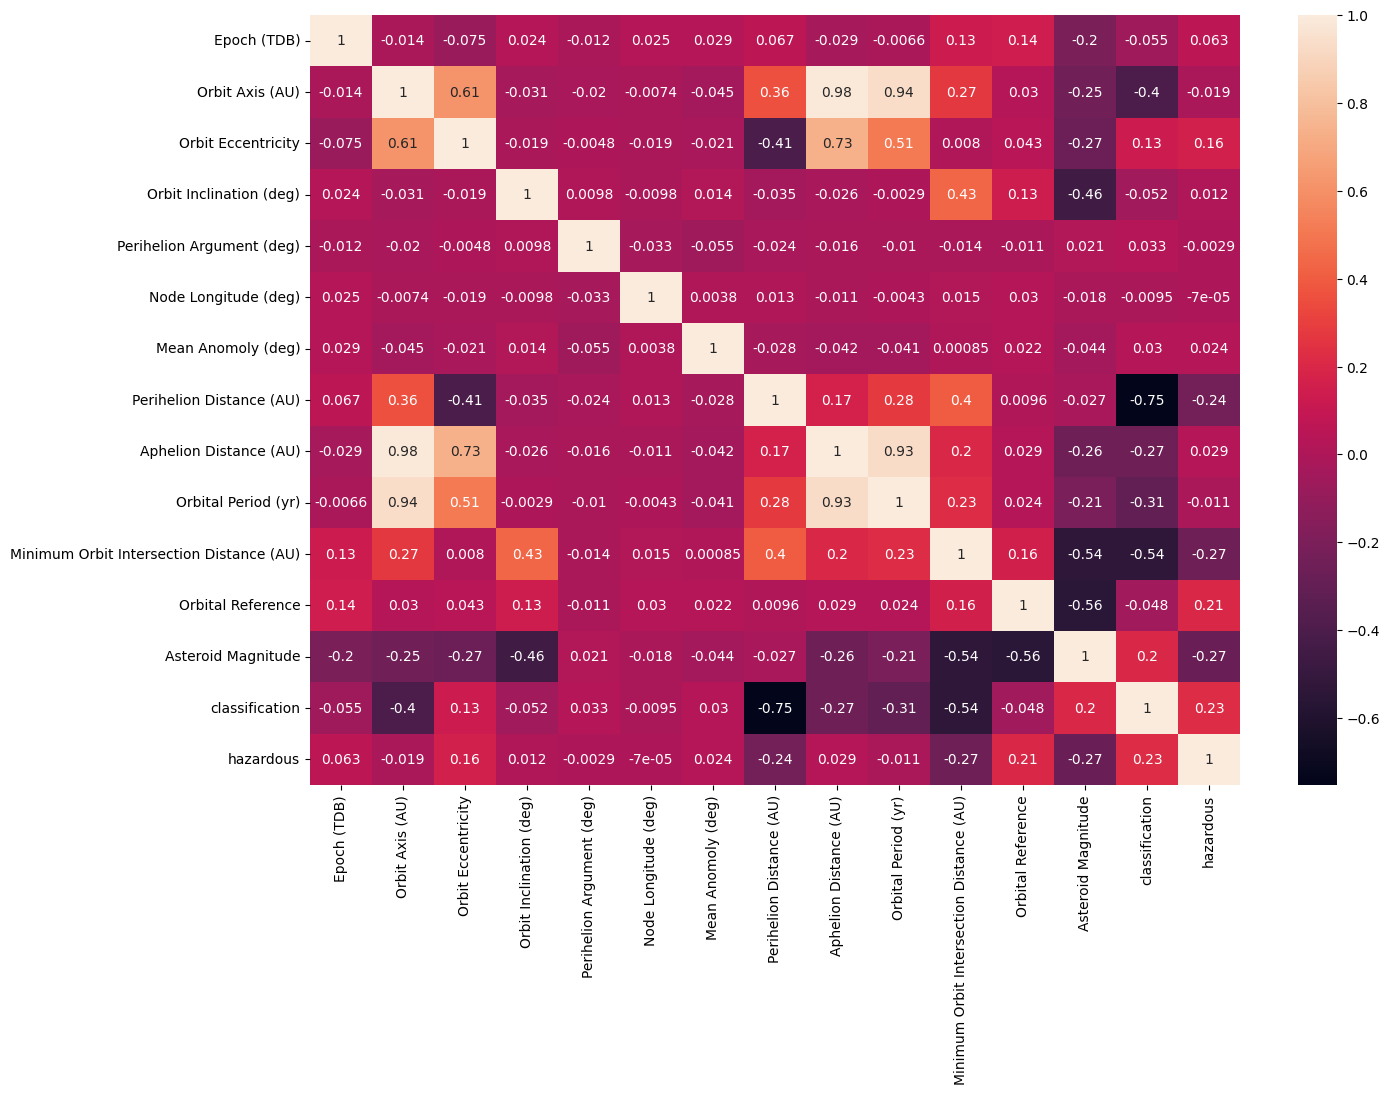

In [12]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.draw()

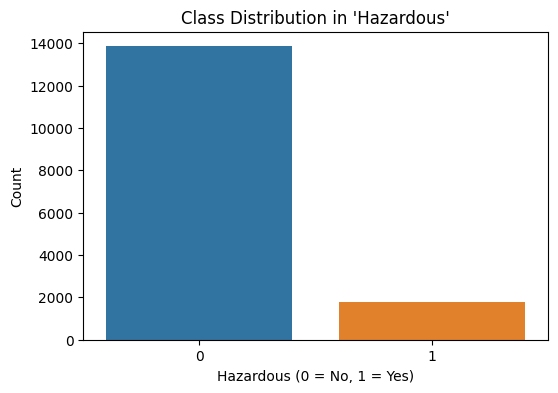

In [13]:
from sklearn.model_selection import train_test_split
x=df.drop(['hazardous'],axis=1)
y=df['hazardous']

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Class Distribution in 'Hazardous'")
plt.xlabel("Hazardous (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [14]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.33,random_state=42,stratify=y)
smote=SMOTE(sampling_strategy=0.5,random_state=42)
xtrain,ytrain=smote.fit_resample(xtrain,ytrain)
print(ytrain.value_counts())


hazardous
0    9282
1    4641
Name: count, dtype: int64


In [15]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)

In [16]:
rf.fit(xtrain,ytrain)

RandomForestClassifier(max_depth=10, random_state=42)

In [17]:
pred=rf.predict(xtest)

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix
a=accuracy_score(ytest,pred)
print(a)
print(confusion_matrix(ytest,pred))

1.0
[[4573    0]
 [   0  587]]
